# Project 1 – Part A: Portfolio Analysis

**Objective:** Build equally-weighted (EW) and value-weighted (VW) portfolios from 30 S&P 500 stocks over 2015-01-01 to 2025-12-31. 
Compare turnover, performance statistics, and cumulative returns against the S&P 500 benchmark and the risk-free rate.

**Key design choices:**
- Monthly rebalancing on the first trading day of each month.
- **1-day information lag**: portfolio weights for a rebalance date are computed using data available as of the *previous* trading day.
- Weights drift with daily returns between rebalances (buy-and-hold drift).
- **Data sources**: Yahoo Finance (`yfinance`) for all prices and metadata. Market cap is proximated by daily price x current shares outstanding.

## 1. Setup

In [21]:
# -- Imports -------------------------------------------------
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

# -- Global constants ----------------------------------------
ANALYSIS_START = '2015-01-01'           # portfolio analysis starts here
DATA_START     = '2014-12-01'           # extra buffer for 1-day lag
END_DATE       = '2025-12-31'
N_STOCKS       = 30
TRADING_DAYS   = 252                    # for annualisation

## 2. Universe Selection (30 Stocks)

We hand-pick 30 current S&P 500 constituents spanning all 11 GICS sectors to ensure 
broad diversification.  The exact tickers used are printed below.

In [22]:
tickers = [
    # Technology
    'AAPL', 'MSFT', 'AVGO', 'CSCO',
    # Communication Services
    'GOOGL', 'META', 'DIS',
    # Consumer Discretionary
    'AMZN', 'MCD', 'NKE',
    # Health Care
    'JNJ', 'UNH', 'PFE', 'ABT',
    # Financials
    'JPM', 'BAC', 'GS',
    # Consumer Staples
    'PG', 'KO',
    # Energy
    'XOM', 'CVX',
    # Materials
    'LIN', 'APD',
    # Utilities
    'NEE', 'DUK',
    # Industrials
    'UNP', 'HON', 'MMM',
    # Real Estate
    'AMT', 'PLD',
]

assert len(tickers) == N_STOCKS, f'Expected {N_STOCKS} tickers, got {len(tickers)}'
print(f'Universe: {len(tickers)} stocks')
print(tickers)

Universe: 30 stocks
['AAPL', 'MSFT', 'AVGO', 'CSCO', 'GOOGL', 'META', 'DIS', 'AMZN', 'MCD', 'NKE', 'JNJ', 'UNH', 'PFE', 'ABT', 'JPM', 'BAC', 'GS', 'PG', 'KO', 'XOM', 'CVX', 'LIN', 'APD', 'NEE', 'DUK', 'UNP', 'HON', 'MMM', 'AMT', 'PLD']


## 3. Data Collection

We download data from **2014-12-01** (one month before our analysis window) so that the 
first rebalance on the first trading day of January 2015 can use the previous trading day's 
information for market-cap weights.

In [23]:
# -- Helper functions: data retrieval -----------------------

def get_prices(tickers, start, end):
    """Download daily adjusted-close prices from Yahoo Finance."""
    data = yf.download(tickers, start=start, end=end,
                       auto_adjust=True, progress=False)['Close']
    return data


def get_market_caps(tickers, prices):
    """
    Proxy daily market cap = daily price x current shares outstanding.
    yfinance does not have point-in-time historical market cap.
    """
    shares = {}
    for t in tickers:
        try:
            info = yf.Ticker(t).info
            # fallback to impliedSharesOutstanding if sharesOutstanding missing
            s = info.get('sharesOutstanding') or info.get('impliedSharesOutstanding') or np.nan
            shares[t] = s
        except:
            shares[t] = np.nan
            
    shares_series = pd.Series(shares)
    # Broadcast shares to all trading days
    mcap = prices * shares_series
    return mcap


def get_benchmark(start, end):
    """Download S&P 500 daily close from Yahoo Finance."""
    data = yf.download('^GSPC', start=start, end=end,
                       auto_adjust=True, progress=False)['Close']
    if isinstance(data, pd.DataFrame):
        data = data.squeeze()
    data.name = 'SP500'
    return data


def get_risk_free(start, end):
    """Download 13-week T-bill yield and convert to a daily rate.

    ^IRX is quoted as an annualised yield in percentage points.
    Daily rate = (yield / 100) / 252.
    """
    irx = yf.download('^IRX', start=start, end=end,
                      auto_adjust=True, progress=False)['Close']
    if isinstance(irx, pd.DataFrame):
        irx = irx.squeeze()
    rf_daily = (irx / 100) / TRADING_DAYS
    rf_daily.name = 'Rf'
    return rf_daily

In [24]:
# -- Download all data ---------------------------------------
prices   = get_prices(tickers, DATA_START, END_DATE)
mcap     = get_market_caps(tickers, prices)
sp500    = get_benchmark(DATA_START, END_DATE)
rf_daily = get_risk_free(DATA_START, END_DATE)

print(f'Prices   : {prices.shape[0]:>5} days x {prices.shape[1]} stocks '
      f'({prices.index[0].date()} -> {prices.index[-1].date()})')
print(f'Mkt Caps : {mcap.shape[0]:>5} days x {mcap.shape[1]} stocks')
print(f'S&P 500  : {len(sp500):>5} days')
print(f'Risk-free: {len(rf_daily):>5} days')

Prices   :  2787 days x 30 stocks (2014-12-01 -> 2025-12-30)
Mkt Caps :  2787 days x 30 stocks
S&P 500  :  2787 days
Risk-free:  2786 days


## 4. Return Construction

Daily simple returns are computed from adjusted prices via `pct_change()`.  
Missing values are **forward-filled** first (stale price assumption); any remaining 
NaN after forward-fill is set to 0 (equivalent to no price change).

In [25]:
def compute_returns(prices):
    """Compute daily simple returns from adjusted prices."""
    return prices.pct_change().iloc[1:]    # drop first NaN row


# Stock returns
stock_returns = compute_returns(prices)
stock_returns = stock_returns.ffill().fillna(0)

# Benchmark returns
sp500_returns = compute_returns(sp500.to_frame()).squeeze()
sp500_returns.name = 'SP500'

# Risk-free aligned to stock trading dates
rf_aligned = rf_daily.reindex(stock_returns.index).ffill().fillna(0)

print(f'Stock returns : {stock_returns.shape}')
print(f'Date range    : {stock_returns.index[0].date()} -> '
      f'{stock_returns.index[-1].date()}')
print(f'Any NaN left  : {stock_returns.isnull().any().any()}')

Stock returns : (2786, 30)
Date range    : 2014-12-02 -> 2025-12-30
Any NaN left  : False


## 5. Portfolio Construction & Rebalancing

**Rebalancing rule (monthly, 1-day information lag):**

1. Identify the **first trading day of each month** as a rebalance date.
2. On a rebalance date, compute target weights using information from the **previous trading day** (1-day lag):
   - **EW**: w_i = 1/N
   - **VW**: w_i = mcap_i / sum(mcap), where market caps are from the previous trading day.
3. Apply target weights on the rebalance date. Between rebalances, weights **drift** with daily returns (buy-and-hold).
4. Daily portfolio return: R_p = sum(w_i * r_i).

In [26]:
def make_rebalance_dates(dates, start):
    """Return the first trading day of each month on or after `start`."""
    filtered = dates[dates >= start]
    return (
        filtered
        .to_series()
        .groupby(filtered.to_period('M'))
        .first()
        .values
    )


def compute_weights_equal(n):
    """Equal weights: 1/n."""
    return 1.0 / n


def compute_weights_value(mcap_row):
    """Value weights: proportional to market cap."""
    w = mcap_row.fillna(0)
    total = w.sum()
    return w / total if total > 0 else w * 0


rebalance_dates = make_rebalance_dates(stock_returns.index, ANALYSIS_START)
print(f'Number of rebalance dates: {len(rebalance_dates)}')
print(f'First: {rebalance_dates[0]}  |  Last: {rebalance_dates[-1]}')

Number of rebalance dates: 132
First: 2015-01-02T00:00:00  |  Last: 2025-12-01T00:00:00


In [27]:
def backtest_portfolio(stock_rets, rebalance_dates, weight_func,
                       mcap=None):
    """
    Run a daily backtest with monthly rebalancing and 1-day info lag.

    Parameters
    ----------
    stock_rets      : DataFrame - daily simple returns (dates x tickers)
    rebalance_dates : array-like - rebalance dates
    weight_func     : str - 'equal' or 'value'
    mcap            : DataFrame - daily market caps (for 'value' only)

    Returns
    -------
    port_rets    : Series - daily portfolio returns
    weights_hist : dict  - {rebalance_date: Series of target weights}
    """
    dates = stock_rets.index
    ticks = stock_rets.columns
    n     = len(ticks)

    reb_set = set(pd.Timestamp(d) for d in rebalance_dates)

    port_rets    = pd.Series(0.0, index=dates, dtype=float)
    weights_hist = {}
    w            = pd.Series(0.0, index=ticks)
    started      = False

    for i, date in enumerate(dates):
        # -- Rebalance? ------------------------------------------
        if date in reb_set:
            prev_date = dates[i - 1] if i > 0 else date   # 1-day lag

            if weight_func == 'equal':
                new_w = pd.Series(compute_weights_equal(n), index=ticks)
            else:   # 'value'
                if prev_date in mcap.index:
                    cap_row = mcap.loc[prev_date, ticks]
                else:
                    idx = mcap.index.get_indexer([prev_date],
                                                method='ffill')[0]
                    if idx >= 0:
                        cap_row = mcap.iloc[idx][ticks]
                    else:
                        cap_row = pd.Series(1.0, index=ticks)  # fallback
                new_w = compute_weights_value(cap_row)

            weights_hist[date] = new_w.copy()
            w = new_w.copy()
            started = True

        if not started:
            continue

        # -- Daily portfolio return ------------------------------
        r = stock_rets.loc[date]
        port_rets.loc[date] = (w * r).sum()

        # -- Drift weights for next day --------------------------
        w = w * (1 + r)
        w_sum = w.sum()
        if w_sum > 0:
            w = w / w_sum

    # Trim to analysis window
    first_reb = pd.Timestamp(rebalance_dates[0])
    port_rets = port_rets.loc[port_rets.index >= first_reb]

    return port_rets, weights_hist

In [28]:
# -- Run both backtests --------------------------------------
ew_rets, ew_weights = backtest_portfolio(
    stock_returns, rebalance_dates, 'equal')

vw_rets, vw_weights = backtest_portfolio(
    stock_returns, rebalance_dates, 'value', mcap=mcap)

# Align benchmark & risk-free to portfolio dates
sp500_aligned = sp500_returns.reindex(ew_rets.index).fillna(0)
rf_port       = rf_aligned.reindex(ew_rets.index).fillna(0)

print(f'EW portfolio days: {len(ew_rets)}')
print(f'VW portfolio days: {len(vw_rets)}')

# Quick sanity check: weights sum to ~1
sample_date = list(ew_weights.keys())[0]
assert abs(ew_weights[sample_date].sum() - 1.0) < 1e-8, 'EW weights do not sum to 1'
assert abs(vw_weights[sample_date].sum() - 1.0) < 1e-8, 'VW weights do not sum to 1'
print('Weight sanity checks passed.')

EW portfolio days: 2765
VW portfolio days: 2765
Weight sanity checks passed.


## 6. Turnover

**Definition used:**

Turnover_t = 0.5 * sum(|w_new - w_drifted|)

where `w_drifted` are the weights just before rebalancing (after buy-and-hold drift from the previous rebalance).  
The 0.5 factor avoids double-counting buys and sells.  Turnover is computed at each rebalance starting from the second one.

In [29]:
def compute_turnover(weights_hist, stock_rets):
    """
    Compute turnover at each rebalance.

    Turnover = 0.5 * sum|w_new - w_drifted|
    where w_drifted are the buy-and-hold drifted weights from the
    previous rebalance to just before the current one.
    """
    reb_dates = sorted(weights_hist.keys())
    turnovers = {}

    for j in range(1, len(reb_dates)):
        prev_reb = reb_dates[j - 1]
        curr_reb = reb_dates[j]

        # Drift weights from previous rebalance through each day
        w = weights_hist[prev_reb].copy()
        period = stock_rets.loc[prev_reb:curr_reb].index

        for d in period:
            if d == curr_reb:
                break
            r = stock_rets.loc[d]
            w = w * (1 + r)
            w_sum = w.sum()
            if w_sum > 0:
                w = w / w_sum

        w_new = weights_hist[curr_reb]
        turnovers[curr_reb] = 0.5 * (w_new - w).abs().sum()

    return pd.Series(turnovers)


ew_turnover = compute_turnover(ew_weights, stock_returns)
vw_turnover = compute_turnover(vw_weights, stock_returns)

print(f'{"Metric":<30} {"EW":>10} {"VW":>10}')
print('-' * 52)
print(f'{"Mean monthly turnover":<30} '
      f'{ew_turnover.mean():>10.4f} {vw_turnover.mean():>10.4f}')
print(f'{"Median monthly turnover":<30} '
      f'{ew_turnover.median():>10.4f} {vw_turnover.median():>10.4f}')
print(f'{"Max monthly turnover":<30} '
      f'{ew_turnover.max():>10.4f} {vw_turnover.max():>10.4f}')
print()
higher = ('Equal-Weighted' if ew_turnover.mean() > vw_turnover.mean()
          else 'Value-Weighted')
print(f'-> The {higher} portfolio has the highest average turnover.')

Metric                                 EW         VW
----------------------------------------------------
Mean monthly turnover              0.0207     0.0000
Median monthly turnover            0.0197     0.0000
Max monthly turnover               0.0385     0.0000

-> The Equal-Weighted portfolio has the highest average turnover.


## 7. Performance Statistics

All metrics are **annualised** from daily returns (252 trading days/year).

| Metric | Formula |
|--------|---------|
| Ann. Return | mean(r) * 252 |
| Ann. Std Dev | std(r) * sqrt(252) |
| Sharpe Ratio | mean(r_excess) / std(r_excess) * sqrt(252), where excess = portfolio - risk-free |
| Information Ratio | mean(r_active) / std(r_active) * sqrt(252), where active = portfolio - S&P 500 |

In [30]:
def compute_stats(port_rets, rf, bench_rets, name):
    """
    Compute annualised performance statistics from daily returns.

    Sharpe  uses excess  returns (portfolio - risk-free).
    Info    uses active  returns (portfolio - benchmark).
    """
    excess = port_rets - rf
    active = port_rets - bench_rets

    ann_ret = port_rets.mean() * TRADING_DAYS
    ann_std = port_rets.std()  * np.sqrt(TRADING_DAYS)
    sharpe  = (excess.mean() / excess.std() * np.sqrt(TRADING_DAYS)
              if excess.std() > 0 else np.nan)
    ir      = (active.mean() / active.std() * np.sqrt(TRADING_DAYS)
              if active.std() > 0 else np.nan)

    return {
        'Portfolio':            name,
        'Ann. Return':          f'{ann_ret:.4f}',
        'Ann. Std Dev':         f'{ann_std:.4f}',
        'Sharpe Ratio':         f'{sharpe:.4f}',
        'Info Ratio (vs S&P)':  f'{ir:.4f}',
    }


stats = [
    compute_stats(ew_rets,       rf_port, sp500_aligned, 'Equal-Weight'),
    compute_stats(vw_rets,       rf_port, sp500_aligned, 'Value-Weight'),
    compute_stats(sp500_aligned, rf_port, sp500_aligned, 'S&P 500'),
]

stats_df = pd.DataFrame(stats).set_index('Portfolio')
stats_df

,Ann. Return,Ann. Std Dev,Sharpe Ratio,Info Ratio (vs S&P)
Portfolio,,,,
Equal-Weight,0.1571,0.1686,0.8149,0.6297
Value-Weight,0.1896,0.1945,0.8736,1.0825
S&P 500,0.1263,0.1791,0.5955,nan


## 8. Cumulative Return Plot

Growth of $1 invested on the first rebalance date.

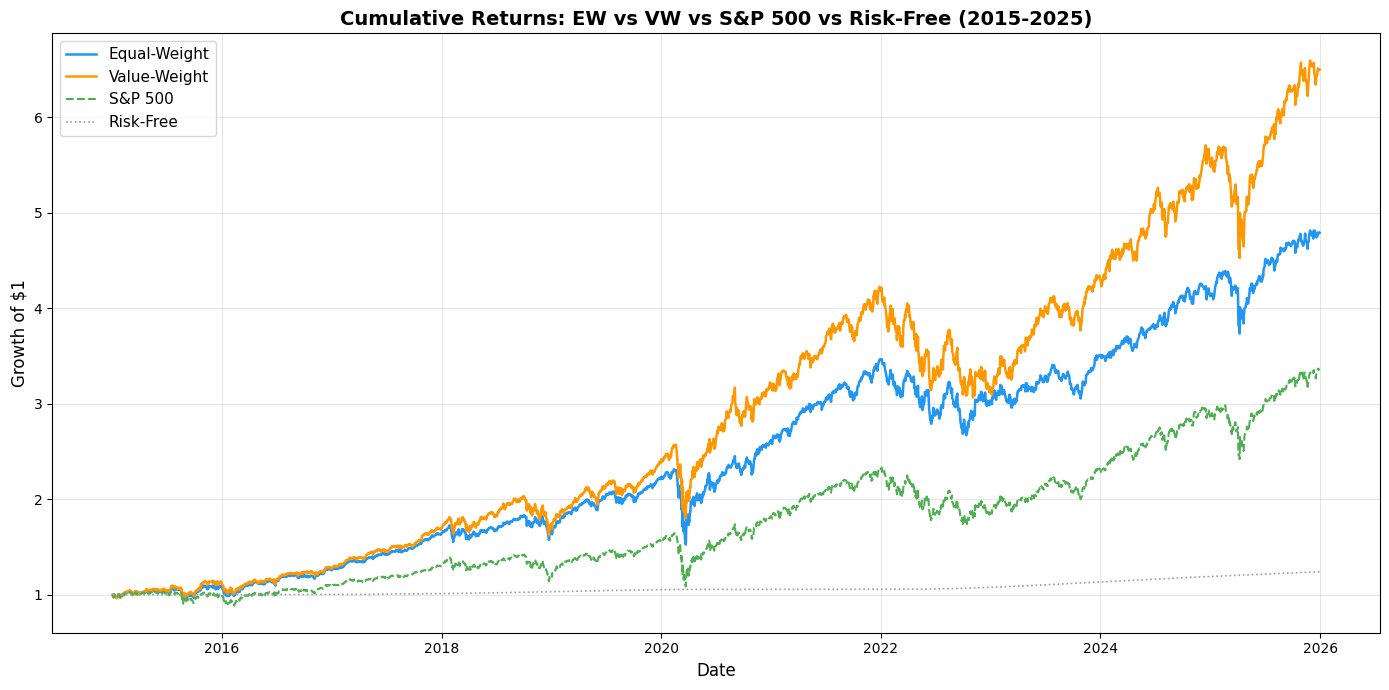

In [31]:
# -- Cumulative returns (growth of $1) -----------------------
cum_ew = (1 + ew_rets).cumprod()
cum_vw = (1 + vw_rets).cumprod()
cum_sp = (1 + sp500_aligned).cumprod()
cum_rf = (1 + rf_port).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(cum_ew.index, cum_ew.values,
        label='Equal-Weight', linewidth=1.8, color='#2196F3')
ax.plot(cum_vw.index, cum_vw.values,
        label='Value-Weight', linewidth=1.8, color='#FF9800')
ax.plot(cum_sp.index, cum_sp.values,
        label='S&P 500',      linewidth=1.5, linestyle='--',
        color='#4CAF50')
ax.plot(cum_rf.index, cum_rf.values,
        label='Risk-Free',    linewidth=1.2, linestyle=':',
        color='#9E9E9E')

ax.set_title('Cumulative Returns: EW vs VW vs S&P 500 vs Risk-Free '
             '(2015-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Growth of $1', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# Part B: Diversification Experiment

**Objective:** Demonstrate how portfolio variance decreases as the number of randomly selected stocks ($n$) increases.

For $n = 1, 2, \dots, 30$:
1. Choose $n$ stocks at random.
2. Compute the variance of the equal-weighted portfolio of those $n$ stocks over the entire historical period.
3. Repeat 10 times and average the variance.

In [32]:
import random

# Pre-calculate annualized covariance matrix of daily stock returns
cov_matrix = stock_returns.cov() * TRADING_DAYS

n_max = len(tickers)
n_simulations = 10
avg_variances = []

np.random.seed(42)
random.seed(42)

for n in range(1, n_max + 1):
    sim_vars = []
    for _ in range(n_simulations):
        # Choose n random stocks
        sample = random.sample(tickers, n)
        # The variance of an equal-weighted portfolio is w.T @ Cov @ w
        w = np.ones(n) / n
        # Extract sub-covariance matrix for the chosen sample
        sample_cov = cov_matrix.loc[sample, sample]
        port_var = w.T @ sample_cov @ w
        sim_vars.append(port_var)
    
    avg_variances.append(np.mean(sim_vars))

avg_variances_s = pd.Series(avg_variances, index=range(1, n_max + 1))

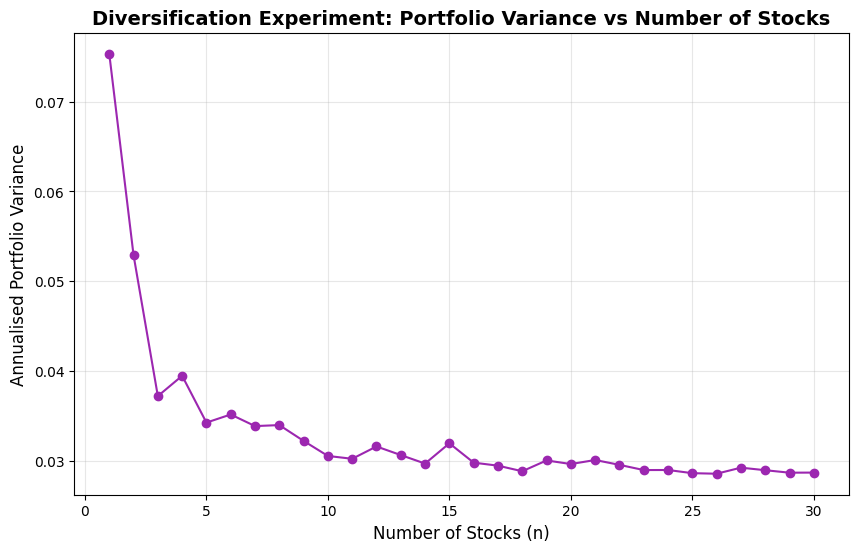

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(avg_variances_s.index, avg_variances_s.values, marker='o', linestyle='-', color='#9C27B0')
ax.set_title('Diversification Experiment: Portfolio Variance vs Number of Stocks', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Stocks (n)', fontsize=12)
ax.set_ylabel('Annualised Portfolio Variance', fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

**Conclusion:** As $n$ increases, the portfolio variance drops sharply at first and then asymptotes. This illustrates the elimination of **idiosyncratic (diversifiable) risk**. The remaining variance (the horizontal asymptote) represents the **systematic (market) risk** of the S&P 500 universe pool.

# Part C: Mean-Variance Optimization

**Objective:** Compute the Efficient Frontier, find the Minimum Variance Portfolio (MVP), and the Tangency (Optimum) Portfolio assuming the expected risk premium is given by the past 10-year excess return.

In [35]:
from scipy.optimize import minimize

# 1. Expected risk premium (10-year average annualized excess return)
ann_rets = stock_returns.mean() * TRADING_DAYS
ann_rf = rf_daily.mean() * TRADING_DAYS # assumption for risk-free rate
risk_premiums = ann_rets - ann_rf

# 2. Annualized covariance matrix (already computed as cov_matrix above)

def portfolio_stats(weights, mu, cov):
    ret = np.dot(weights, mu)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    sharpe = ret / vol
    return ret, vol, sharpe

In [36]:
n_assets = len(tickers)
init_guess = np.ones(n_assets) / n_assets
bounds = tuple((0.0, 1.0) for _ in range(n_assets)) # long-only
cons_sum_to_one = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}

# A. Minimum Variance Portfolio (MVP)
def min_vol_obj(w, cov):
    return np.dot(w.T, np.dot(cov, w))

res_mvp = minimize(min_vol_obj, init_guess, args=(cov_matrix,),
                   method='SLSQP', bounds=bounds, constraints=cons_sum_to_one)
w_mvp = res_mvp.x
ret_mvp, vol_mvp, _ = portfolio_stats(w_mvp, risk_premiums, cov_matrix)

# B. Optimum (Tangency) Portfolio (Max Sharpe Ratio)
def neg_sharpe_obj(w, mu, cov):
    return -portfolio_stats(w, mu, cov)[2]

res_tan = minimize(neg_sharpe_obj, init_guess, args=(risk_premiums, cov_matrix),
                   method='SLSQP', bounds=bounds, constraints=cons_sum_to_one)
w_tan = res_tan.x
ret_tan, vol_tan, sharpe_tan = portfolio_stats(w_tan, risk_premiums, cov_matrix)

In [37]:
# Generate the Efficient Frontier (30 assets)
if ret_tan > risk_premiums.max():
    max_ret = ret_tan + 0.05
else:
    max_ret = risk_premiums.max() + 0.02

target_rets = np.linspace(ret_mvp, max_ret, 50)
frontier_vols = []

for r in target_rets:
    cons = [cons_sum_to_one, {'type': 'eq', 'fun': lambda x: np.dot(x, risk_premiums) - r}]
    res = minimize(min_vol_obj, init_guess, args=(cov_matrix,),
                   method='SLSQP', bounds=bounds, constraints=cons)
    frontier_vols.append(np.sqrt(res.fun))

In [38]:
# 2-Asset Frontier with varying correlation
# Let's pick AAPL and MSFT
asset1, asset2 = 'AAPL', 'MSFT'
idx1, idx2 = tickers.index(asset1), tickers.index(asset2)

mu1, mu2 = risk_premiums[asset1], risk_premiums[asset2]
vol1, vol2 = np.sqrt(cov_matrix.loc[asset1, asset1]), np.sqrt(cov_matrix.loc[asset2, asset2])

rhos = [-1.0, -0.5, 0.0, 0.5, 1.0]
w_grid = np.linspace(0, 1, 100)
two_asset_frontiers = {}

for rho in rhos:
    vols, rets = [], []
    cov_12 = rho * vol1 * vol2
    for w in w_grid:
        r_p = w * mu1 + (1 - w) * mu2
        v_p = np.sqrt(w**2 * vol1**2 + (1 - w)**2 * vol2**2 + 2 * w * (1 - w) * cov_12)
        rets.append(r_p)
        vols.append(v_p)
    two_asset_frontiers[rho] = (vols, rets)

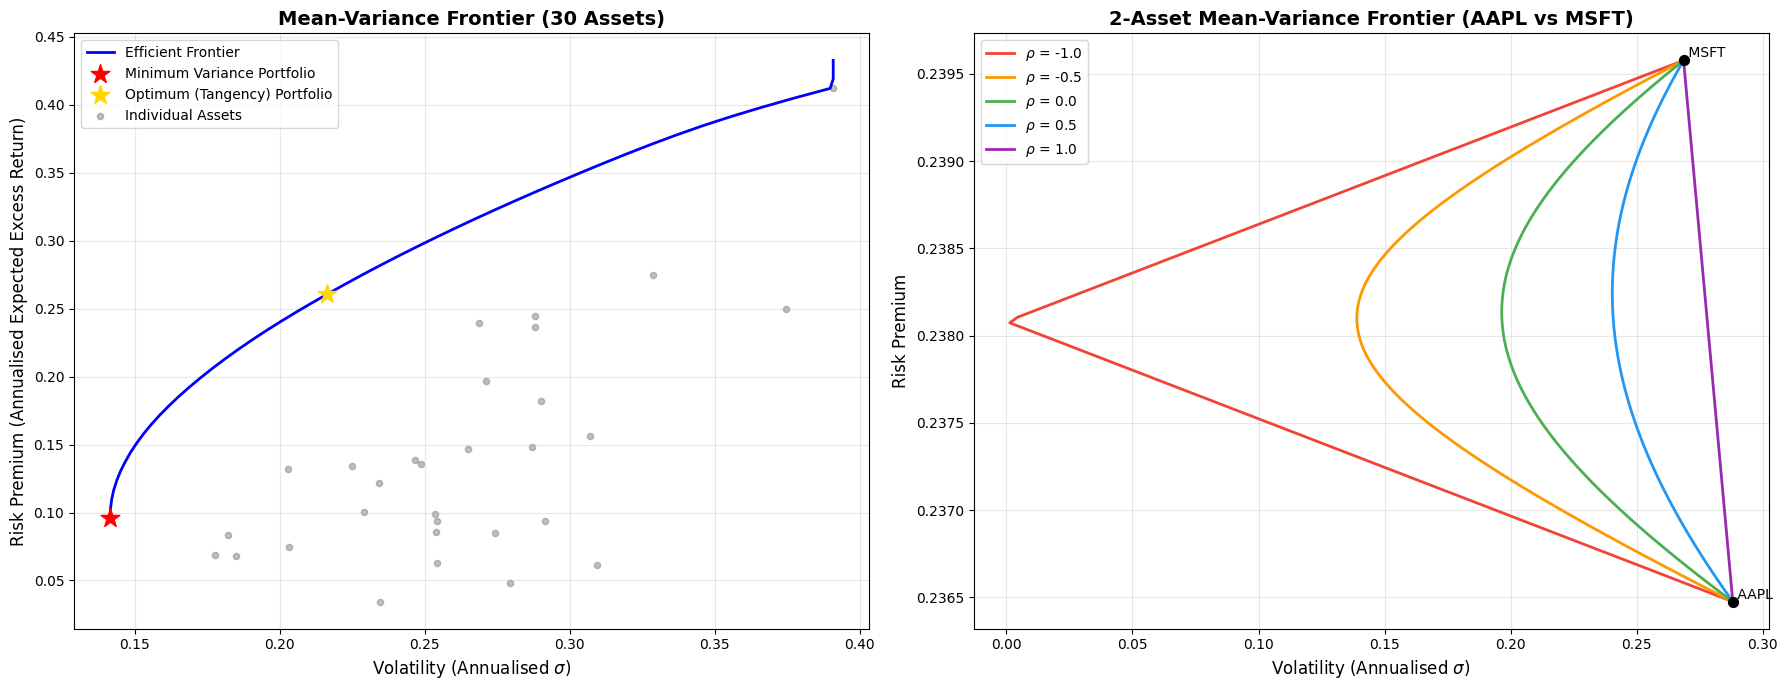

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: 30-Asset Efficient Frontier ---
ax1.plot(frontier_vols, target_rets, 'b-', label='Efficient Frontier', linewidth=2)
ax1.scatter([vol_mvp], [ret_mvp], color='red', marker='*', s=200, zorder=5, label='Minimum Variance Portfolio')
ax1.scatter([vol_tan], [ret_tan], color='gold', marker='*', s=200, zorder=5, label='Optimum (Tangency) Portfolio')

# Scatter individual assets
asset_vols = np.sqrt(np.diag(cov_matrix))
ax1.scatter(asset_vols, risk_premiums, color='grey', alpha=0.5, s=20, label='Individual Assets')

ax1.set_title('Mean-Variance Frontier (30 Assets)', fontsize=14, fontweight='bold')
ax1.set_xlabel(r'Volatility (Annualised $\sigma$)', fontsize=12)
ax1.set_ylabel('Risk Premium (Annualised Expected Excess Return)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: 2-Asset Correlation Playground ---
colors = ['#F44336', '#FF9800', '#4CAF50', '#2196F3', '#9C27B0']
for (rho, (vols, rets)), color in zip(two_asset_frontiers.items(), colors):
    ax2.plot(vols, rets, label=rf'$\rho$ = {rho}', color=color, linewidth=2)

ax2.scatter([vol1, vol2], [mu1, mu2], color='black', s=50, zorder=5)
ax2.text(vol1, mu1, f' {asset1}', verticalalignment='bottom')
ax2.text(vol2, mu2, f' {asset2}', verticalalignment='bottom')

ax2.set_title(f'2-Asset Mean-Variance Frontier ({asset1} vs {asset2})', fontsize=14, fontweight='bold')
ax2.set_xlabel(r'Volatility (Annualised $\sigma$)', fontsize=12)
ax2.set_ylabel('Risk Premium', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()